In [ ]:
import os
os.chdir("/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/models")
import tensorflow as tf
from params import PARAMS
from PreDamagePreTech import PreDamagePreTechModel
from TwoStageTechJump_FOCIr_orignal.simulations.SimulationDeterministic  import load_PreDamagePreTech_model, simulate_path_PreDamagePreTech
 
# Example usage
import numpy as np 
import pathlib
import time
from feedforward_subnet import FeedForwardSubNet, setup_optimizers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output/TwoStageTech_LR_piecewiseconstant_40e-6,40e-6,40e-6,40e-6_128_neurons_32_#HiddenLayer_4_num_iterations2000000' 
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output/TwoStageTech_LR_warmup_cosine_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output/TwoStageTech_LR_piecewiseconstant_10e-6,40e-4_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output/TwoStageTech_LR_piecewiseconstant_10e-6,40e-6_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output/TwoStageTech_LR_warmup_cosine_10e-6,10e-4_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output/TwoStageTech_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output_SITE_Pretrain/TwoStageTech_LR_warmup_cosine_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations2000000'
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output_001/TwoStageTech_LR_warmup_cosine_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_num_iterations1000000'
# Promising one
export_folder    = '/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/output_001/TwoStageTech_LR_warmup_cosine_10e-6,10e-4_128_neurons_32_#HiddenLayer_4_num_iterations1000000' 


batch_size                       = int("128")
num_iterations                   = int("2000000")
pretrained_path = None
logging_frequency                = 1000
learning_rates                   = [float(x) for x in "10e-4,10e-4,10e-4,10e-4".split(",")]
hidden_layer_activations         = "swish,tanh,tanh,softplus".split(",")
output_layer_activations         = "softplus,custom,custom,softplus".split(",")
num_hidden_layers                = int("4")
num_neurons                      = int("32")
learning_rate_schedule_type      = "piecewiseconstant"
export_folder_output             = "DeterministicSimulation"
    
    
hidden_layer_activations   = [None if x == "None" else x for x in hidden_layer_activations]
output_layer_activations   = [None if x == "None" else x for x in output_layer_activations]


v_nn_config   = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[0], "dim" : 1, "nn_name" : "v_nn"}
v_nn_config["final_activation"] = output_layer_activations[0]

i_g_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[1], "dim" : 1, "nn_name" : "i_g_nn"}
i_g_nn_config["final_activation"] = output_layer_activations[1]

i_d_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[2], "dim" : 1, "nn_name" : "i_d_nn"}
i_d_nn_config["final_activation"] = output_layer_activations[2]


i_r_nn_config = {"num_hiddens" : [num_neurons for _ in range(num_hidden_layers)], "use_bias" : True, "activation" : hidden_layer_activations[3], "dim" : 1, "nn_name" : "i_r_nn"}
i_r_nn_config["final_activation"] = output_layer_activations[3]

params = {"batch_size" : batch_size, "learning_rates":learning_rates,
"v_nn_config" : v_nn_config, "i_g_nn_config" : i_g_nn_config, "i_d_nn_config" : i_d_nn_config, "i_r_nn_config" : i_r_nn_config,
"num_iterations" : num_iterations, "logging_frequency": logging_frequency, "verbose": True, 
"pretrained_path" : pretrained_path, "learning_rate_schedule_type" : learning_rate_schedule_type}

params["export_folder"]  = export_folder +  "/PreDamagePreTech"
params["job_name"] =export_folder
params["v_PostDamagePostTech_nn_path"]  = export_folder +  "/PostDamagePostTech/v_nn_checkpoint_PostDamagePostTech"
params["v_PreDamagePostTech_nn_path"]  = export_folder +  "/PreDamagePostTech/v_nn_checkpoint_PreDamagePostTech"
params["v_PostDamagePreTech_nn_path"]  = export_folder +  "/PostDamagePreTech/v_nn_checkpoint_PostDamagePreTech"
params["v_PostDamageIntermTech_nn_path"]  = export_folder +  "/PostDamageIntermTech/v_nn_checkpoint_PostDamageIntermTech"
params["v_PreDamageIntermTech_nn_path"]  = export_folder +  "/PreDamageIntermTech/v_nn_checkpoint_PreDamageIntermTech"
## i_g and i_d activations come after params because we amy want to use phi_g and phi_d
phi_g = 16.7
phi_d = 16.7
if output_layer_activations[1] == "custom" or output_layer_activations[2] == "custom":
    params["i_g_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ phi_g) / (tf.exp(2 * x) + 1.0)
    params["i_d_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ phi_d) / (tf.exp(2 * x) + 1.0)

PARAMS.update(params)

model = load_PreDamagePreTech_model(export_folder)
print("Loaded PreDamagePreTech model with value, controls, and helper nets.")



Loaded PreDamagePreTech model with value, controls, and helper nets.


In [ ]:
_=simulate_path_PreDamagePreTech(
    model,
    ξ= 148.6 ,
    T=60.0,
    dt=1/12,  ) 

_= simulate_path_PreDamagePreTech(
    model,
    ξ= 0.3,
    T=60.0,
    dt=1/12,  )

_=simulate_path_PreDamagePreTech(
    model,
    ξ= 0.1,
    T=60.0,
    dt=1/12,  )
 
_=simulate_path_PreDamagePreTech(
    model,
    ξ= 0.05,
    T=60.0,
    dt=1/12,  )


Climate (damage) models distorted weights over λ3: [0.19972447 0.19987945 0.20001945 0.20014    0.20023665]
Climate sensitivity distortion shift (varsigma * h_y_T): 5.2444208376982715e-09
[0.96003161 0.03996839]
Climate (damage) models distorted weights over λ3: [0.09331437 0.13634391 0.19161619 0.25623253 0.322493  ]
Climate sensitivity distortion shift (varsigma * h_y_T): 2.6313367886468767e-06
[0.97475741 0.02524259]
Climate (damage) models distorted weights over λ3: [0.01359875 0.04224038 0.11668119 0.27749985 0.5499798 ]
Climate sensitivity distortion shift (varsigma * h_y_T): 7.715911779552699e-06
[0.98998033 0.01001967]
Climate (damage) models distorted weights over λ3: [4.7996698e-04 4.6042558e-03 3.4903772e-02 1.9600965e-01 7.6400232e-01]
Climate sensitivity distortion shift (varsigma * h_y_T): 1.5120331685990095e-05
[0.99734636 0.00265364]


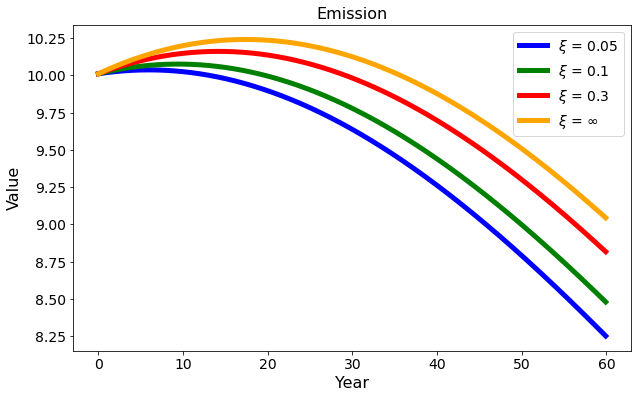

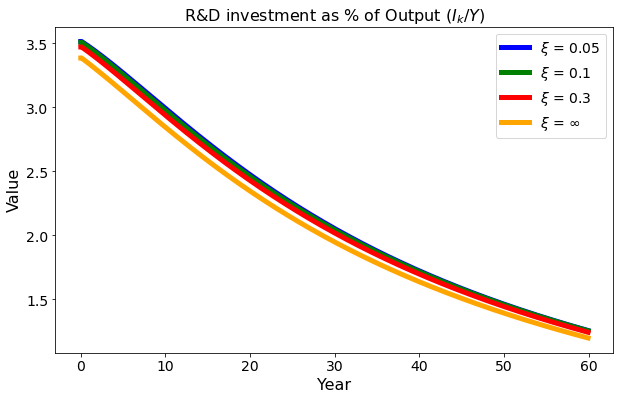

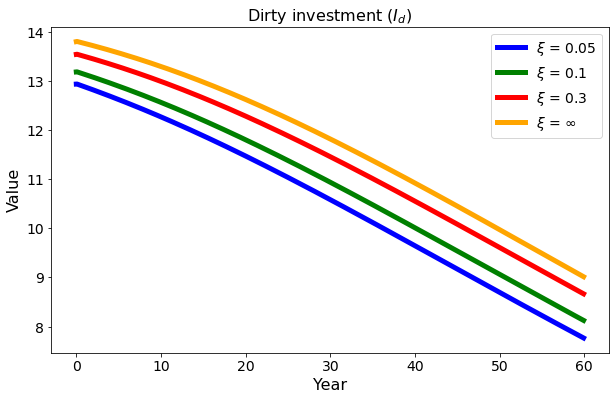

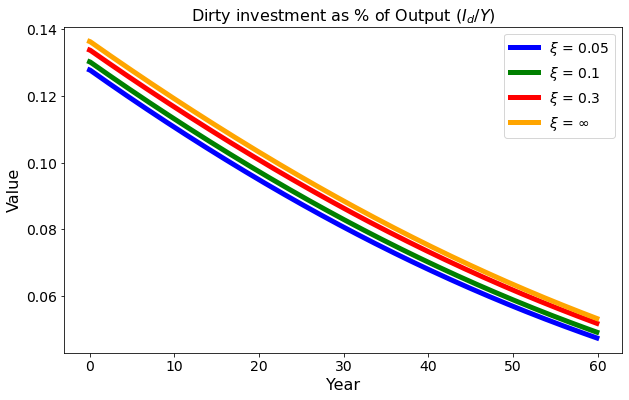

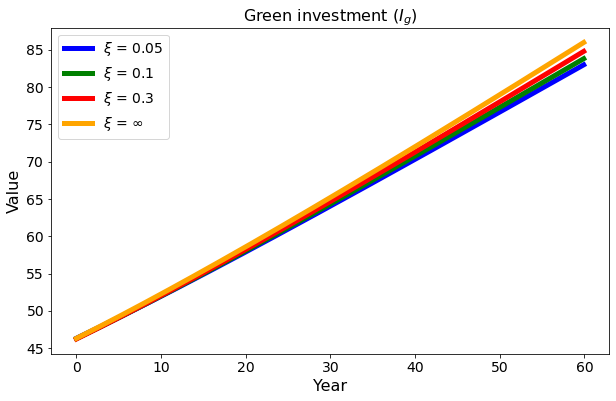

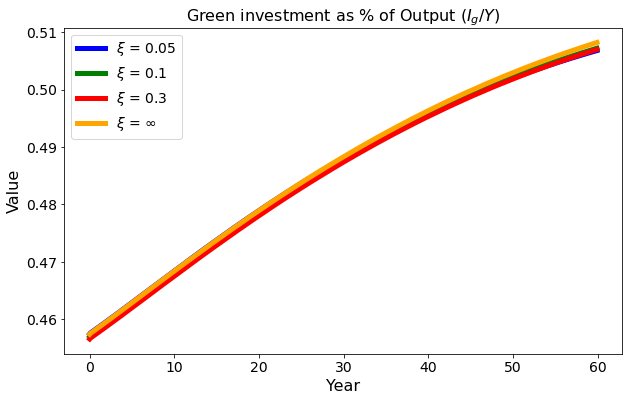

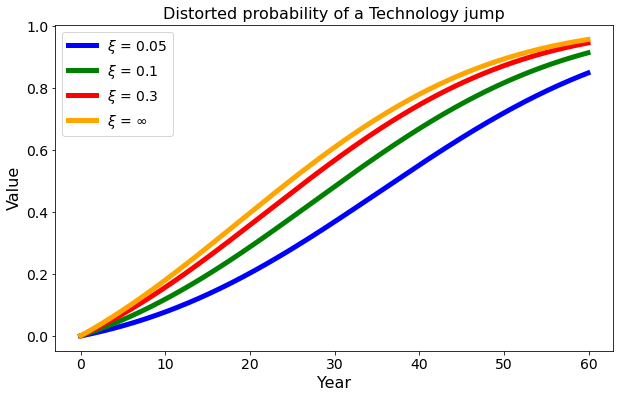

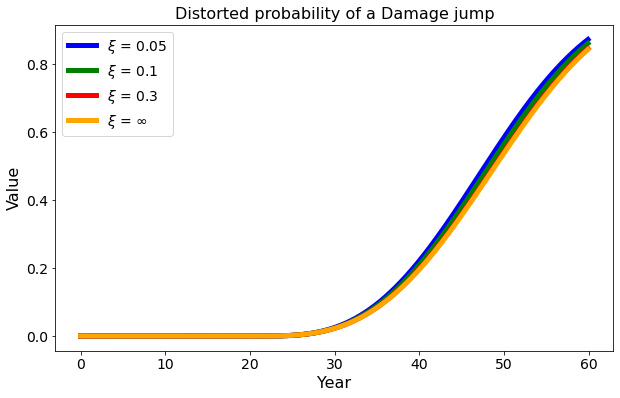

In [ ]:
 
FolderName=export_folder 

# Function to read values from a file
def read_values(file_path):
    values = []
    with open(file_path, 'r') as file:
        for line in file:
            values.append(float(line.strip()))
    return values

Name=["E","RD","I_d","DirtyInvestment","I_g","GreenInvestment","tech_jump_prob","dmg_jump_prob" ]
for txt_name in Name:
    # File paths 5, -1. -3
    # Cap_damage/TwoCapital_NN/output/A_g_prime_1_Delta_0.01_LR_piecewiseconstant_10e-5,10e-5,10e-5,10e-5_128_neurons_32_#HiddenLayer_4_logxi_-3.0_logximax_5.0_num_iterations600000
    file_path1 = FolderName+f'/PreDamagePreTech/SimulationOutputs_ξ_0.050/{txt_name}.txt'
    file_path2 = FolderName+f'/PreDamagePreTech/SimulationOutputs_ξ_0.100/{txt_name}.txt'
    file_path3 = FolderName+f'/PreDamagePreTech/SimulationOutputs_ξ_0.300/{txt_name}.txt'
    # file_path4 = FolderName+f'/PreDamagePreTech/SimulationOutputs_ξ_5.000/{txt_name}.txt'
    file_path5 = FolderName+f'/PreDamagePreTech/SimulationOutputs_ξ_148.600/{txt_name}.txt'

  
    # Read values from the files
    values1 = read_values(file_path1)
    values2 = read_values(file_path2)
    values3 = read_values(file_path3)
    # values4 = read_values(file_path4)
    values5 = read_values(file_path5)
    values1 = values1[:720]  
    values2 = values2[:720]
    values3 = values3[:720]
    # values4 = values4[:720]
    values5 = values5[:720]
    # Indices for the values
    indices1 = [x / 12 for x in range(len(values1))]
    indices2 = [x / 12 for x in range(len(values2))]
    indices3 = [x / 12 for x in range(len(values3))]
    # indices4 = [x / 12 for x in range(len(values4))]
    indices5 = [x / 12 for x in range(len(values5))]

    # Plotting the values from both files
    plt.figure(figsize=(10, 6))

    if txt_name == "RD" or txt_name == "DirtyInvestment" or txt_name == "GreenInvestment":
        values1 = [v * 100 for v in values1]
        values2 = [v * 100 for v in values2]
        values3 = [v * 100 for v in values3]
        # values4 = [v * 100 for v in values4]
        values5 = [v * 100 for v in values5]
    
    plt.plot(indices1, values1,  color='b', label=r'$\xi$ = 0.05',linewidth=5)
    plt.plot(indices2, values2,  color='g', label=r'$\xi$ = 0.1',linewidth=5)
    plt.plot(indices3, values3,  color='r', label=r'$\xi$ = 0.3',linewidth=5)
    # plt.plot(indices4, values4,  color='purple', label=r'$\xi$ = 5.0',linewidth=5)
    plt.plot(indices5, values5,  color='orange', label=r'$\xi$ = $\infty$',linewidth=5)
    
    if txt_name == "RD":
        plt.title(r'R&D investment as % of Output $(I_k/Y)$',fontsize=16)
#         plt.ylim(0, 3) 
    elif txt_name =="I_d":
        plt.title(r'Dirty investment $(I_d)$',fontsize=16)
#         plt.ylim(8, 18) 
    elif txt_name =="I_g":
        plt.title(r'Green investment $(I_g)$',fontsize=16)
#         plt.ylim(25, 50) 
    elif txt_name =="tech_jump_prob":
        plt.title('Distorted probability of a Technology jump',fontsize=16)
    elif txt_name =="dmg_jump_prob":
        plt.title('Distorted probability of a Damage jump',fontsize=16)
    elif txt_name =="TechJumpIntensity":
        plt.title('Distorted Intensity of a Technology jump',fontsize=16)
    elif txt_name =="DmgJumpIntensity":
        plt.title('Distorted Intensity of a Damage jump',fontsize=16)    
    elif txt_name =="E":
        plt.title('Emission',fontsize=16)  
#         plt.ylim(6, 13 ) 
    elif txt_name =="DirtyInvestment":
        plt.title('Dirty investment as % of Output $(I_d/Y)$',fontsize=16)
    elif txt_name =="GreenInvestment":
        plt.title('Green investment as % of Output $(I_g/Y)$',fontsize=16)
    else:
        plt.title(f'{txt_name}',fontsize=16)
    plt.xlabel('Year',fontsize=16)
    plt.ylabel('Value',fontsize=16)
    plt.xticks(fontsize=14)  
    plt.yticks(fontsize=14)  
    plt.legend(fontsize=14)  
    plt.show()

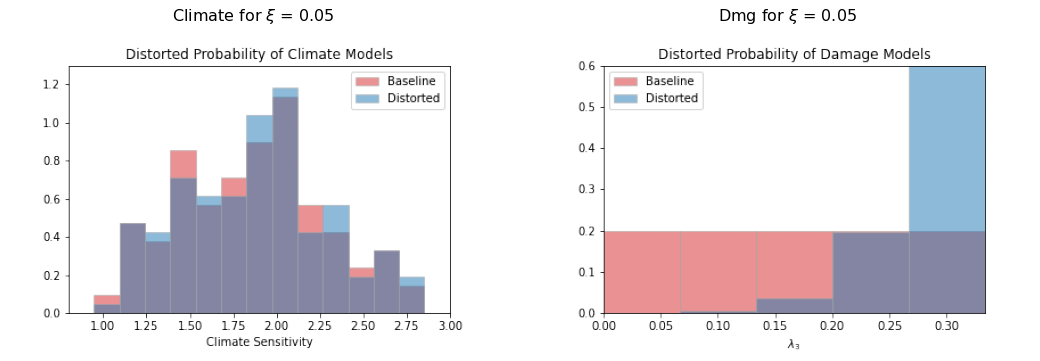

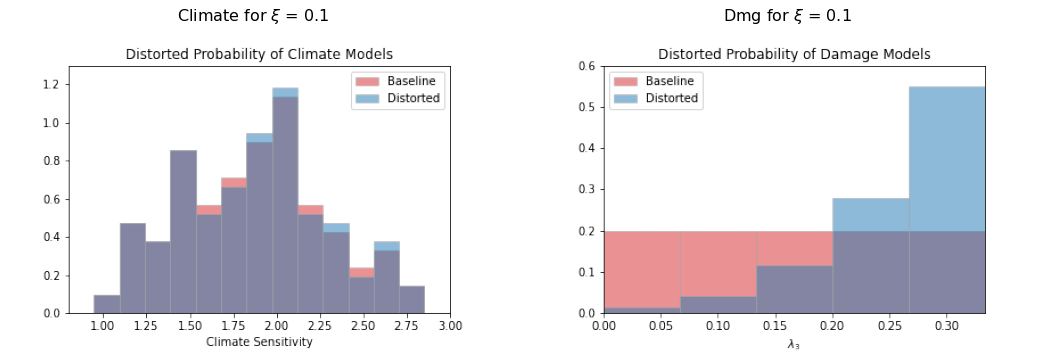

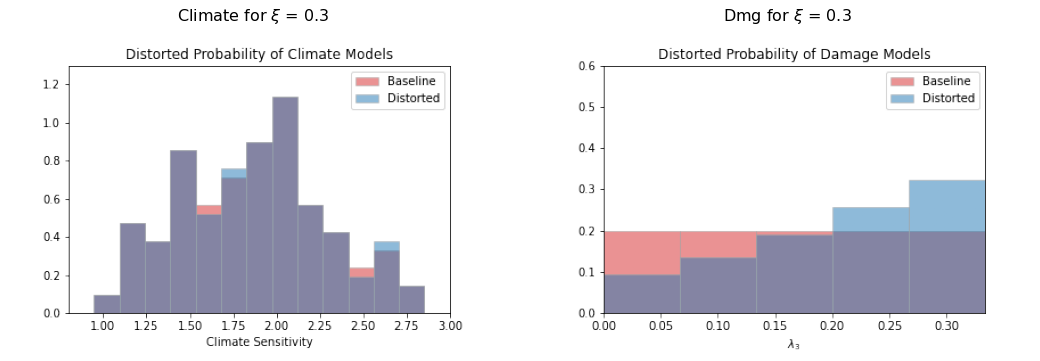

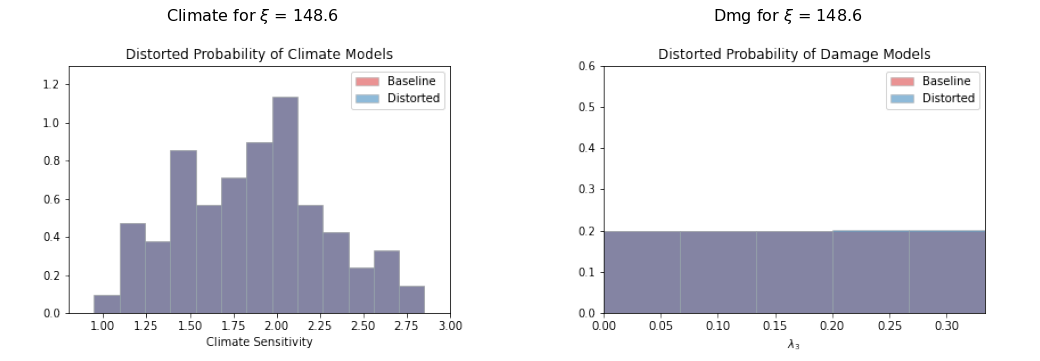

In [4]:
# Image types to display
ImageTypes = ["Climate_Dist.png", "Dmg_Dist.png"]

# Labels for xi values
xi_values = [ "0.050", "0.100", "0.300", "148.600"]
xi_labels = [ r'$\xi$ = 0.05', r'$\xi$ = 0.1',   r'$\xi$ = 0.3', r'$\xi$ = 148.6']

# Loop through each xi value
for idx, xi in enumerate(xi_values):
    plt.figure(figsize=(15, 5))  # Make space for multiple plots
    
    # Load and display each type of image
    for i, img_type in enumerate(ImageTypes):
        img_path = f"{FolderName}/PreDamagePreTech/SimulationOutputs_ξ_{xi}/{img_type}"
        img = mpimg.imread(img_path)
        plt.subplot(1, len(ImageTypes), i + 1)  # 1 row, N columns
        plt.imshow(img)
        plt.title(img_type.split("_")[0] + f' for {xi_labels[idx]}', fontsize=16)
        plt.axis("off")  # Hide axes

    plt.tight_layout()
    plt.show()